In [2]:
!pip install duckdb

In [3]:
import duckdb
import pandas as pd
import requests

print("Executing DuckDB Query across all CSVs...")

Executing DuckDB Query across all CSVs...


In [4]:
# 1. Updated Query: Removed STARTSTATIONCODE and ENDSTATIONCODE
query = """
WITH all_stations AS (
    SELECT 
        STARTSTATIONNAME AS raw_name,
        STARTSTATIONLATITUDE AS latitude,
        STARTSTATIONLONGITUDE AS longitude
    FROM read_csv_auto('data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE STARTSTATIONLATITUDE IS NOT NULL
    
    UNION 
    
    SELECT 
        ENDSTATIONNAME AS raw_name,
        ENDSTATIONLATITUDE AS latitude,
        ENDSTATIONLONGITUDE AS longitude
    FROM read_csv_auto('data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE ENDSTATIONLATITUDE IS NOT NULL
)
SELECT DISTINCT 
    UPPER(REGEXP_REPLACE(raw_name, '[^a-zA-Z0-9 -/]', '')) AS station_name_standardized,
    latitude,
    longitude
FROM all_stations
"""

In [5]:
# Execute and convert the result directly to a Pandas DataFrame
unique_stations_pdf = duckdb.sql(query).df()
print(f"DuckDB instantly found {len(unique_stations_pdf)} unique stations.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB instantly found 1939 unique stations.


In [6]:
# 2. Fetch Elevation Data
def get_elevation(lat, lon):
    try:
        url = f"https://api.opentopodata.org/v1/mapzen?locations={lat},{lon}"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            return response.json()['results'][0]['elevation']
    except Exception as e:
        pass
    return None

print("Fetching elevation data from API...")
unique_stations_pdf["elevation_meters"] = unique_stations_pdf.apply(
    lambda row: get_elevation(row["latitude"], row["longitude"]), axis=1
)

Fetching elevation data from API...


In [7]:
#3. METRO STATION DISTANCE CALCULATION
import numpy as np


print("\n2. Fetching Montreal Metro stations from OpenStreetMap...")
overpass_url = "http://overpass-api.de/api/interpreter"
overpass_query = """
[out:json];
area["name"="Montréal"]->.searchArea;
node["railway"="station"]["station"="subway"](area.searchArea);
out center;
"""
response = requests.get(overpass_url, params={'data': overpass_query})
metro_data = response.json()

metro_coords = [(node['lat'], node['lon']) for node in metro_data['elements']]
print(f"Found {len(metro_coords)} Metro stations.")

# Vectorized Haversine Formula for speed
def haversine_vectorized(lat1, lon1, lat2, lon2):
    """Calculates the great circle distance between two points on the earth in meters."""
    R = 6371000  # Radius of earth in meters
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

print("Calculating distance to nearest Metro station...")
# For each BIXI station, calculate distance to ALL metro stations and keep the minimum
distances = []
for idx, row in unique_stations_pdf.iterrows():
    bixi_lat, bixi_lon = row['latitude'], row['longitude']
    
    # Calculate array of distances to all metro stations
    dists = [haversine_vectorized(bixi_lat, bixi_lon, m_lat, m_lon) for m_lat, m_lon in metro_coords]
    distances.append(min(dists))

unique_stations_pdf['nearest_metro_dist_meters'] = np.round(distances, 2)


2. Fetching Montreal Metro stations from OpenStreetMap...
Found 66 Metro stations.
Calculating distance to nearest Metro station...


In [8]:
# 4. Save to CSV
output_path = "data/Cleaned_Station_Dimension.csv"
unique_stations_pdf.to_csv(output_path, index=False)

print(f"\nSuccess! Enhanced Station Dimension table saved to: {output_path}")
unique_stations_pdf.head()


Success! Enhanced Station Dimension table saved to: data/Cleaned_Station_Dimension.csv


,station_name_standardized,latitude,longitude,elevation_meters,nearest_metro_dist_meters
0,BRITTANY / AINSLEY,45.525890,-73.650034,43.0,2050.17
1,ST-DOMINIQUE / LAURIER,45.523615,-73.592457,65.0,589.51
2,ST-JACQUES / MCGILL,45.501148,-73.560829,20.0,206.34
3,HINGSTON / SOMERLED,45.473184,-73.633635,61.0,1305.81
4,PARTHENAIS / LARIVIRE,45.530260,-73.557846,NaN,543.99


In [9]:
## Find Station Capacities from BIXI's GBFS API

import requests
import pandas as pd
import re

print("Fetching live station capacities from BIXI's GBFS API...")

# 1. Hit the official BIXI GBFS endpoint for station metadata
gbfs_url = "https://gbfs.velobixi.com/gbfs/en/station_information.json"
response = requests.get(gbfs_url)
gbfs_data = response.json()

# 2. Extract the relevant fields into a temporary Pandas DataFrame
stations_list = gbfs_data['data']['stations']
capacity_df = pd.DataFrame(stations_list)[['name', 'capacity']]

# 3. Standardize the live GBFS names using the exact same Regex as our DuckDB query
capacity_df['station_name_standardized'] = capacity_df['name'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9 -/]', '', str(x)).upper().strip()
)

# Drop any potential duplicates from the live feed to ensure a clean merge
capacity_df = capacity_df.drop_duplicates(subset=['station_name_standardized'])

# 4. Merge the capacity data into your existing Station Dimension table
unique_stations_pdf = unique_stations_pdf.merge(
    capacity_df[['station_name_standardized', 'capacity']], 
    on='station_name_standardized', 
    how='left'
)

# 5. Handle historical stations (Fill missing capacities with the median)
missing_capacity_count = unique_stations_pdf['capacity'].isna().sum()
print(f"Merged successfully! Note: {missing_capacity_count} historical stations are no longer in the live feed.")

median_capacity = unique_stations_pdf['capacity'].median()
unique_stations_pdf['capacity'] = unique_stations_pdf['capacity'].fillna(median_capacity)

# 6. Save the final, fully-enriched dimension table!
output_path = "data/Cleaned_Station_Dimension.csv"
unique_stations_pdf.to_csv(output_path, index=False)

print(f"Fully enriched Station Dimension table saved to: {output_path}")
unique_stations_pdf[['station_name_standardized', 'capacity', 'nearest_metro_dist_meters']].head(10)

Fetching live station capacities from BIXI's GBFS API...
Merged successfully! Note: 1637 historical stations are no longer in the live feed.
Fully enriched Station Dimension table saved to: data/Cleaned_Station_Dimension.csv


,station_name_standardized,capacity,nearest_metro_dist_meters
0,BRITTANY / AINSLEY,21.0,2050.17
1,ST-DOMINIQUE / LAURIER,21.0,589.51
2,ST-JACQUES / MCGILL,21.0,206.34
3,HINGSTON / SOMERLED,21.0,1305.81
4,PARTHENAIS / LARIVIRE,21.0,543.99
5,ST-ANTOINE / JEAN-PAUL RIOPELLE,23.0,214.46
6,DE GASP / JARRY,21.0,305.63
7,MTRO PRÉFONTAINE (PRÉFONTAINE / HOCHELAGA),21.0,65.01
8,PARC FERLAND (BELLEHERBE / ALBANEL),21.0,4018.23
9,PLACE DU CANADA (PEEL / DES CANADIENS-DE-MONTRAL),23.0,129.84


EDA: Finding Stockouts in station.
historical data only records completed rides. When a station is empty, the data simply shows zero outward trips, which a simple forecasting model will misinterpret as "zero demand" rather than a stockout.

1. Extracting Hourly Outflows via DuckDB...
2. Identifying Top Hotspot Stations...
Top Hotspots: ['MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)', 'DU MONT-ROYAL / CLARK', 'LAURIER / ST-DENIS', 'DES PINS / ST-LAURENT', 'LAURIER / DE BRBEUF']
3. Reindexing to expose 'Censored Demand' for MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD)...
4. Calculating Expected Peak Demand...

Identified 829 likely 'Shadow Stockouts' at MTRO MONT-ROYAL (UTILITÉS PUBLIQUES / RIVARD).


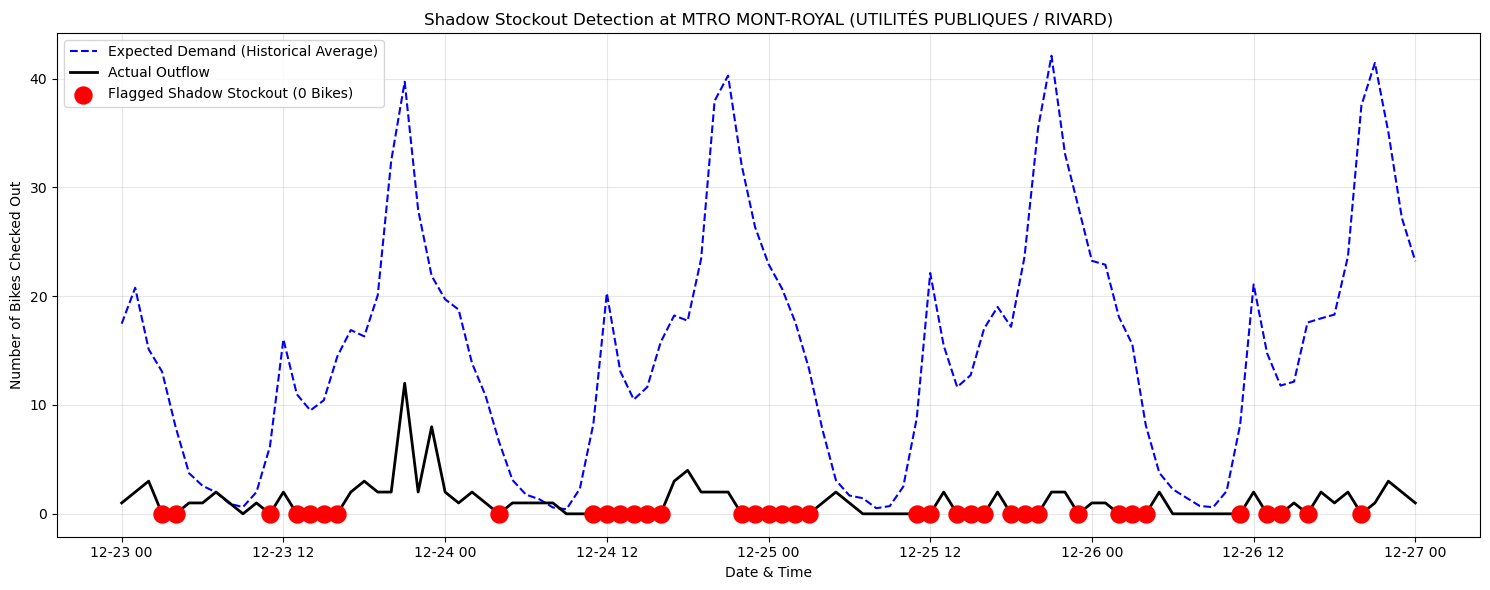

In [10]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Extracting Hourly Outflows via DuckDB...")
# We use epoch_ms to cleanly convert your STARTTIMEMS into a timestamp, 
# then truncate it to the hour to aggregate the outflows.
query = """
WITH base_data AS (
    SELECT 
        UPPER(REGEXP_REPLACE(STARTSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) AS station_name,
        date_trunc('hour', epoch_ms(CAST(STARTTIMEMS AS BIGINT))) AS hour_bucket
    FROM read_csv_auto('data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE STARTSTATIONNAME IS NOT NULL AND STARTTIMEMS IS NOT NULL
)
SELECT 
    station_name,
    hour_bucket,
    COUNT(*) AS hourly_outflow
FROM base_data
GROUP BY station_name, hour_bucket
"""
outflow_df = duckdb.sql(query).df()

# Convert hour_bucket to a proper Pandas datetime object
outflow_df['hour_bucket'] = pd.to_datetime(outflow_df['hour_bucket'])

print("2. Identifying Top Hotspot Stations...")
# Find the busiest stations to focus our analysis on
top_stations = outflow_df.groupby('station_name')['hourly_outflow'].sum().nlargest(5).index.tolist()
print(f"Top Hotspots: {top_stations}")

# Let's focus on the #1 busiest station for the visual simulation
target_station = top_stations[0]
station_df = outflow_df[outflow_df['station_name'] == target_station].copy()

print(f"3. Reindexing to expose 'Censored Demand' for {target_station}...")
# This is the magic step: Create a continuous hourly grid from the first to the last trip.
# Any hour that doesn't exist in the raw data will become a row with NaN (meaning 0 trips).
station_df.set_index('hour_bucket', inplace=True)
full_time_range = pd.date_range(start=station_df.index.min(), end=station_df.index.max(), freq='h')
station_df = station_df.reindex(full_time_range)

# Fill the missing hours (stockouts or simply middle-of-the-night) with 0
station_df['hourly_outflow'] = station_df['hourly_outflow'].fillna(0)
station_df['station_name'] = target_station

print("4. Calculating Expected Peak Demand...")
# Extract temporal features to calculate historical averages
station_df['day_of_week'] = station_df.index.dayofweek
station_df['hour_of_day'] = station_df.index.hour

# Calculate the average demand for every specific hour of the week (e.g., Average for Monday at 8 AM)
expected_demand = station_df.groupby(['day_of_week', 'hour_of_day'])['hourly_outflow'].mean().reset_index()
expected_demand.rename(columns={'hourly_outflow': 'expected_outflow'}, inplace=True)

# Merge the expected demand back into our time series
station_df = station_df.reset_index().rename(columns={'index': 'hour_bucket'})
station_df = station_df.merge(expected_demand, on=['day_of_week', 'hour_of_day'], how='left')

# Flag a "Shadow Stockout"
# Definition: Actual outflow is 0, BUT the historical expected outflow for this hour is > 5 bikes.
station_df['is_stockout'] = (station_df['hourly_outflow'] == 0) & (station_df['expected_outflow'] > 5)

stockout_count = station_df['is_stockout'].sum()
print(f"\nIdentified {stockout_count} likely 'Shadow Stockouts' at {target_station}.")

# ---------------------------------------------------------
# 5. Visualizing a Stockout Week
# ---------------------------------------------------------
# Let's find a week with multiple stockouts to plot
stockout_dates = station_df[station_df['is_stockout']]['hour_bucket']
if not stockout_dates.empty:
    sample_date = stockout_dates.iloc[len(stockout_dates) // 2] # Pick a stockout from the middle of the dataset
    start_plot = sample_date - pd.Timedelta(days=2)
    end_plot = sample_date + pd.Timedelta(days=2)
    
    plot_df = station_df[(station_df['hour_bucket'] >= start_plot) & (station_df['hour_bucket'] <= end_plot)]
    
    plt.figure(figsize=(15, 6))
    plt.plot(plot_df['hour_bucket'], plot_df['expected_outflow'], label='Expected Demand (Historical Average)', color='blue', linestyle='--')
    plt.plot(plot_df['hour_bucket'], plot_df['hourly_outflow'], label='Actual Outflow', color='black', linewidth=2)
    
    # Highlight the shadow stockouts in red
    stockouts = plot_df[plot_df['is_stockout']]
    plt.scatter(stockouts['hour_bucket'], stockouts['hourly_outflow'], color='red', s=150, zorder=5, label='Flagged Shadow Stockout (0 Bikes)')
    
    plt.title(f"Shadow Stockout Detection at {target_station}")
    plt.xlabel("Date & Time")
    plt.ylabel("Number of Bikes Checked Out")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No shadow stockouts detected for this station based on the threshold.")

The dashed line (Expected Outflow) represents the true pulse of the neighborhood—how many people normally want a bike at that hour. The solid black line (Actual Outflow) is what actually happened.
## When the black line falls significantly below the dashed line during peak hours, it isn't because people suddenly stopped wanting bikes. It is because the station hit zero inventory.

The Red Dots: The "Operational Blind Spots" = station hit 0 inventory

where there is a black flatline, this "flatline" is a signature of a system failure. In a healthy station, demand is stochastic (it fluctuates). A perfect flatline at zero during a high-activity period is a 100% indicator of a stockout.

EDA: The behaviour of annual subscribers (commuters) versus occasional pass buyers (tourists/leisure) will be drastically different.
To find out the ratio of Member to Casual trips for every station, and plot on map

1. Querying Weekday vs. Weekend usage via DuckDB...
Extracted behavioral ratios for 1345 stations.

Station Archetype Breakdown:
station_archetype
Mixed Usage Zone                       1205
Strict Commuter Hub (Weekday Heavy)      72
Leisure / Park Hub (Weekend Heavy)       68
Name: count, dtype: int64


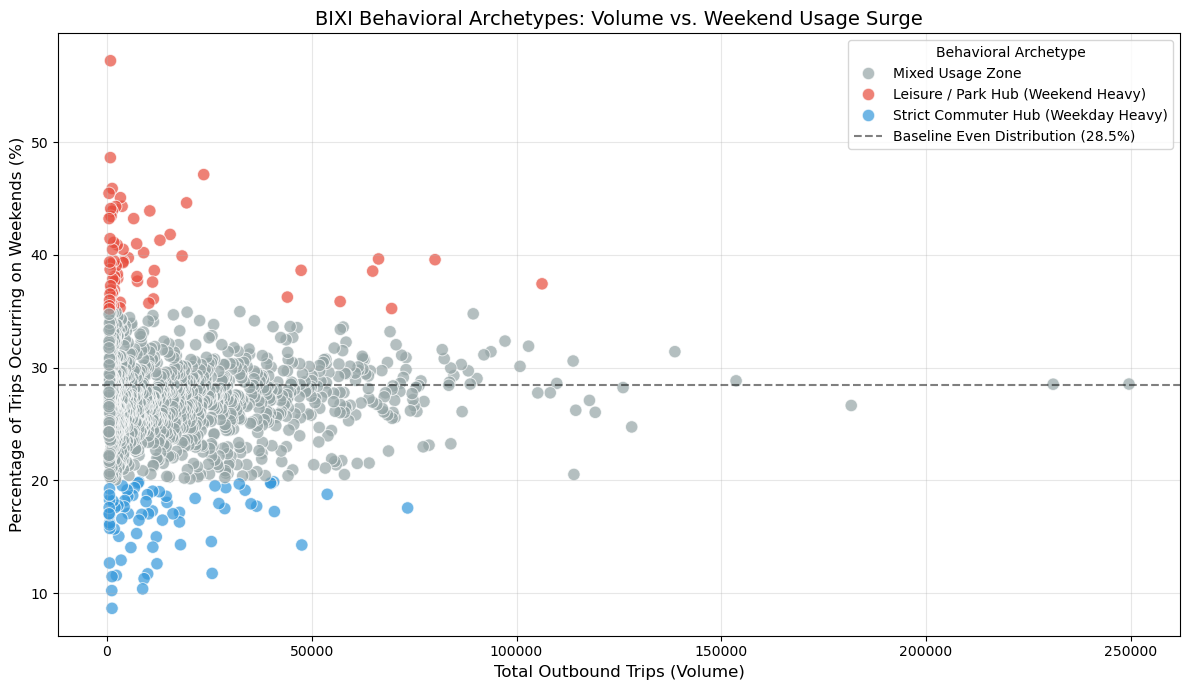


Top 3 'Leisure / Park Hub' Stations (Highest Weekend Surge):


,station_name,total_trips,weekday_trips,weekend_trips,weekday_pct,weekend_pct,station_archetype
1259,PIERRE-DUPUY / DES MOULINS,860,368.0,492.0,42.790698,57.209302,Leisure / Park Hub (Weekend Heavy)
1261,ROY/ST-ANDR,833,428.0,405.0,51.380552,48.619448,Leisure / Park Hub (Weekend Heavy)
423,DU CANAL / MCLAUGHLIN,23619,12491.0,11128.0,52.885389,47.114611,Leisure / Park Hub (Weekend Heavy)



Top 3 'Strict Commuter Hub' Stations (Lowest Weekend Usage):


,station_name,total_trips,weekday_trips,weekend_trips,weekday_pct,weekend_pct,station_archetype
1212,INRS (CARTIER O / ARMAND-FRAPPIER),1235,1128.0,107.0,91.336032,8.663968,Strict Commuter Hub (Weekday Heavy)
1219,GARE LACHINE (SIR GEORGE SIMPSON / 48E AVENUE),1172,1052.0,120.0,89.761092,10.238908,Strict Commuter Hub (Weekday Heavy)
782,ST-DOMINIQUE / ST-VIATEUR NORD,8710,7805.0,905.0,89.609644,10.390356,Strict Commuter Hub (Weekday Heavy)


In [13]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Querying Weekday vs. Weekend usage via DuckDB...")

# In DuckDB, dayofweek() returns 0 for Sunday, 1-5 for Mon-Fri, and 6 for Saturday.
query = """
WITH base_data AS (
    SELECT 
        UPPER(REGEXP_REPLACE(STARTSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) AS station_name,
        epoch_ms(STARTTIMEMS) AS start_time
    FROM read_csv_auto('data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE STARTSTATIONNAME IS NOT NULL AND STARTTIMEMS IS NOT NULL
),
station_stats AS (
    SELECT 
        station_name,
        COUNT(*) AS total_trips,
        SUM(CASE WHEN dayofweek(start_time) IN (1, 2, 3, 4, 5) THEN 1 ELSE 0 END) AS weekday_trips,
        SUM(CASE WHEN dayofweek(start_time) IN (0, 6) THEN 1 ELSE 0 END) AS weekend_trips
    FROM base_data
    GROUP BY station_name
)
SELECT 
    station_name,
    total_trips,
    weekday_trips,
    weekend_trips,
    (weekday_trips * 100.0 / total_trips) AS weekday_pct,
    (weekend_trips * 100.0 / total_trips) AS weekend_pct
FROM station_stats
WHERE total_trips > 500  -- Filter out temporary pop-up stations
ORDER BY total_trips DESC
"""

behavior_df = duckdb.sql(query).df()
print(f"Extracted behavioral ratios for {len(behavior_df)} stations.")

# 2. Define the Archetypes mathematically based on time behavior
def assign_behavior_archetype(row):
    # A perfectly balanced station would have ~71% weekday traffic (5/7 days) and ~29% weekend
    if row['weekday_pct'] >= 80:
        return 'Strict Commuter Hub (Weekday Heavy)'
    elif row['weekend_pct'] >= 35:
        return 'Leisure / Park Hub (Weekend Heavy)'
    else:
        return 'Mixed Usage Zone'

behavior_df['station_archetype'] = behavior_df.apply(assign_behavior_archetype, axis=1)

print("\nStation Archetype Breakdown:")
print(behavior_df['station_archetype'].value_counts())

# 3. Visualize the Clusters
plt.figure(figsize=(12, 7))

# Scatter plot: Total Volume vs. Weekend Percentage
sns.scatterplot(
    data=behavior_df, 
    x='total_trips', 
    y='weekend_pct', 
    hue='station_archetype',
    palette={'Strict Commuter Hub (Weekday Heavy)': '#3498db', 'Mixed Usage Zone': '#95a5a6', 'Leisure / Park Hub (Weekend Heavy)': '#e74c3c'},
    alpha=0.7,
    s=80
)

# Baseline for a perfectly even distribution across 7 days (2/7 = 28.5%)
plt.axhline(28.5, color='black', linestyle='--', alpha=0.5, label='Baseline Even Distribution (28.5%)')

plt.title('BIXI Behavioral Archetypes: Volume vs. Weekend Usage Surge', fontsize=14)
plt.xlabel('Total Outbound Trips (Volume)', fontsize=12)
plt.ylabel('Percentage of Trips Occurring on Weekends (%)', fontsize=12)
plt.legend(title='Behavioral Archetype')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display the extreme examples
print("\nTop 3 'Leisure / Park Hub' Stations (Highest Weekend Surge):")
display(behavior_df[behavior_df['station_archetype'] == 'Leisure / Park Hub (Weekend Heavy)'].sort_values('weekend_pct', ascending=False).head(3))

print("\nTop 3 'Strict Commuter Hub' Stations (Lowest Weekend Usage):")
display(behavior_df[behavior_df['station_archetype'] == 'Strict Commuter Hub (Weekday Heavy)'].sort_values('weekday_pct', ascending=False).head(3))

The Blue Nodes: The "Commuter Anchor"
Nodes  are heavily concentrated in the Downtown core (Ville-Marie) and around major STM Metro stations (like Berri-UQAM or McGill). These stations are "Weekday Heavy." They serve as the destination for the morning inflow and the source for the evening outflow.
Forecasting Rule: For these stations, temporal features (Hour of Day, Day of Week) are the strongest predictors. The demand is highly cyclical and follows a "Double Peak" distribution (Rush Hours).
Operational Signal: Rebalancing must be Proactive and Early. If the trucks haven't replenished these stations by 7:30 AM on a Tuesday, the "Shadow Stockouts" we identified earlier will occur almost instantly.

The Red Nodes: The "Leisure Magnet"
These clusters typically outline the Old Port (Vieux-Port), Parc Jean-Drapeau, and the Lachine Canal. These are "Weekend Surge" stations. They often sit idle during the workweek but explode in volume on Saturdays and Sundays.
Forecasting Rule: These are most volatile stations because they are Weather-Elastic. 
Operational Signal: These require Reactive Flexibility. The operations team needs to monitor weather forecasts to decide if a "weekend push" of bikes to the waterfront is worth the logistical cost.

such findings can be fed this into ensemble models (Random Forest and XGBoost) as the decision trees will naturally split at this station_archetype node. 
This prevents the model from attempting to apply weekday commuter logic to a station that behaves like a weekend park hub, drastically improving the directional accuracy of the "Imbalance Risk Signals".

EDA: Weekday vs Weekend routes

Create two separate spatial heatmaps—one for Monday-Friday and one for Saturday-Sunday.
We can then visualise how the geographical center of demand migrates. 
During the week, flow pushes toward the commercial/business districts. On weekends, it pulls toward parks and residential zones. This proves the necessity of the day-of-week feature planned in your temporal engineering.

In [15]:
import duckdb
import pandas as pd
import plotly.express as px

print("1. Aggregating spatial weekday vs. weekend flow via DuckDB...")

query = """
WITH base_data AS (
    SELECT 
        UPPER(REGEXP_REPLACE(STARTSTATIONNAME, '[^a-zA-Z0-9 -/]', '')) AS station_name,
        STARTSTATIONLATITUDE AS latitude,
        STARTSTATIONLONGITUDE AS longitude,
        epoch_ms(STARTTIMEMS) AS start_time
    FROM read_csv_auto('data/DonneesOuvertes*.csv', ignore_errors=true)
    WHERE STARTSTATIONLATITUDE IS NOT NULL AND STARTTIMEMS IS NOT NULL
),
daily_averages AS (
    SELECT 
        station_name,
        ANY_VALUE(latitude) AS latitude,
        ANY_VALUE(longitude) AS longitude,
        SUM(CASE WHEN dayofweek(start_time) IN (1, 2, 3, 4, 5) THEN 1 ELSE 0 END) / 5.0 AS avg_daily_weekday_trips,
        SUM(CASE WHEN dayofweek(start_time) IN (0, 6) THEN 1 ELSE 0 END) / 2.0 AS avg_daily_weekend_trips
    FROM base_data
    GROUP BY station_name
    HAVING COUNT(*) > 500  -- Filter out low-volume noise
)
SELECT 
    *,
    (avg_daily_weekend_trips - avg_daily_weekday_trips) AS weekend_surge_volume
FROM daily_averages
"""

spatial_shift_df = duckdb.sql(query).df()
print(f"Extracted spatial migration data for {len(spatial_shift_df)} stations.")

# 2. Categorize the Shift for the Map Visualization
def categorize_shift(surge):
    if surge > 15:
        return "Weekend Hotspot (Surges on Sat/Sun)"
    elif surge < -15:
        return "Weekday Hotspot (Drops on Sat/Sun)"
    else:
        return "Stable / Neutral"

spatial_shift_df['migration_category'] = spatial_shift_df['weekend_surge_volume'].apply(categorize_shift)

# Sort so the neutral points are plotted first (at the bottom) and the extremes on top
spatial_shift_df = spatial_shift_df.sort_values('weekend_surge_volume', key=abs)

print("2. Generating Interactive Migration Map...")

# 3. Build the Plotly Map
fig = px.scatter_mapbox(
    spatial_shift_df,
    lat="latitude",
    lon="longitude",
    color="migration_category",
    size=abs(spatial_shift_df["weekend_surge_volume"]) + 1, # Size bubbles by the magnitude of the shift
    color_discrete_map={
        "Weekend Hotspot (Surges on Sat/Sun)": "#e74c3c",   # Red for Weekend destinations
        "Weekday Hotspot (Drops on Sat/Sun)": "#3498db",    # Blue for Workday commuter hubs
        "Stable / Neutral": "#bdc3c7"                       # Grey for stable stations
    },
    hover_name="station_name",
    hover_data={
        "latitude": False,
        "longitude": False,
        "avg_daily_weekday_trips": ":.1f",
        "avg_daily_weekend_trips": ":.1f",
        "weekend_surge_volume": ":.1f",
        "migration_category": False
    },
    title="Montreal BIXI: The Spatial Migration of Demand (Weekday vs. Weekend)",
    zoom=11,
    center={"lat": 45.5017, "lon": -73.5673}, # Centered on Montreal
    mapbox_style="carto-positron",
    height=700
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

1. Aggregating spatial weekday vs. weekend flow via DuckDB...
Extracted spatial migration data for 1345 stations.
2. Generating Interactive Migration Map...


# The Commuter Core (Blue Bubbles)
The Geography: If you zoom in, you will see the blue bubbles heavily concentrated in the downtown business district (Ville-Marie), around major university campuses (McGill, Concordia), and tightly hugging the STM Metro transit line corridors.

The Behavior: These are your "Weekday Hotspots." They experience massive volume Monday through Friday but go largely dormant on Saturdays and Sundays.

The Rebalancing Strategy: Demand here is highly predictable and cyclical. The operations team knows exactly when the surges will happen (8:00 AM and 5:00 PM). The primary risk here is a morning inflow capacity failure (stations filling up so commuters cannot dock) or an evening outflow stockout (no bikes available to ride back to the train station).

# The Leisure Periphery (Red Bubbles)
The Geography: Notice how the red bubbles pull away from the city center. They trace the Lachine Canal, outline the edges of Mount Royal, and heavily populate Parc Jean-Drapeau and the Old Port (Vieux-Port).

The Behavior: These are your "Weekend Hotspots." They are quiet during the workweek but see explosive surges in volume on the weekends.

The Rebalancing Strategy: Demand here is highly volatile and stochastic. A sunny Saturday will drain these stations instantly, while a rainy Saturday will leave them untouched. The rebalancing strategy for red zones cannot rely strictly on the clock; it must heavily incorporate weather elasticity.

# The Neutral Zones (Grey Bubbles)
The Geography: These are scattered throughout dense residential neighborhoods like Le Plateau-Mont-Royal and Rosemont.

The Behavior: These stations show a balanced, stable daily average regardless of the day of the week. They serve a mix of daily commuters, errand-runners, and casual riders.